# Customer Churn Prediction - Professional Model Building

This notebook performs:
- Train-test safe preprocessing
- ColumnTransformer + Pipeline
- Multiple model comparison
- Evaluation using classification metrics and ROC-AUC
- Best model saving

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load Cleaned Dataset
df = pd.read_csv("../data/processed/cleaned_customer_churn.csv")
df.head()

,Age,Gender,Income,SpendingScore,PurchaseAmount,ProductCategory,PaymentMethod,City,State,Country,IsActive,Returns,DiscountUsed,ReviewScore,Browser,Device,SessionTime,Churn,DaysSinceLastPurchase
0,41,Female,35167,65,3992,Beauty,UPI,Delhi,DL,Ind,Y,2.0,False,3.315200,Firefox,Desktop,253,0,0
1,63,Male,20636,38,4968,Clothing,Card,Hyderabad,TN,India,No,0.0,False,2.189086,Edge,Mobile,214,1,0
2,34,Female,29854,78,2807,Clothing,UPI,Delhi,MH,In,N,2.0,True,3.760838,Chrome,Mobile,61,1,0
3,54,Female,108678,82,3305,Beauty,Cash,Chennai,DL,Ind,Y,2.0,True,3.188211,Chrome,Mobile,167,1,0
4,67,Female,114929,49,4407,Beauty,Card,Hyderabad,TN,Ind,N,1.0,False,3.003102,Firefox,Tablet,296,1,0


In [3]:
#Define Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
#Identify Numeric and Categorical Columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['Age', 'Income', 'SpendingScore', 'PurchaseAmount', 'Returns', 'ReviewScore', 'SessionTime', 'DaysSinceLastPurchase']
Categorical Features: ['Gender', 'ProductCategory', 'PaymentMethod', 'City', 'State', 'Country', 'IsActive', 'Browser', 'Device']


In [5]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4000, 18)
X_test shape: (1000, 18)


In [7]:
#Numeric Preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [8]:
#Categorical Preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [9]:
#Combine Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [10]:
#Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [11]:
#Evaluation Function
results = []
trained_models = {}

In [12]:
#Train and Evaluate Models
for model_name, model in models.items():
    
    if model_name == "Naive Bayes":
        # Naive Bayes needs dense array after preprocessing
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()
            X_test_processed = X_test_processed.toarray()

        model.fit(X_train_processed, y_train)
        y_pred = model.predict(X_test_processed)
        y_prob = model.predict_proba(X_test_processed)[:, 1]

        trained_models[model_name] = (preprocessor, model)

    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        trained_models[model_name] = pipeline

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

In [13]:
#Compare Results
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.496,0.498221,0.557769,0.526316,0.508632
3,Naive Bayes,0.499,0.500911,0.547809,0.523311,0.505512
1,KNN,0.498,0.500000,0.517928,0.508806,0.503470
4,SVM,0.497,0.499014,0.503984,0.501487,0.519688
5,Random Forest,0.483,0.484970,0.482072,0.483516,0.490382
2,Decision Tree,0.473,0.474645,0.466135,0.470352,0.473028


In [14]:
#Best Model Name
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [15]:
#Best Model Object
best_model = trained_models[best_model_name]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [16]:
#Predictions on Test Data
if best_model_name == "Naive Bayes":
    X_test_processed = preprocessor.transform(X_test)
    if hasattr(X_test_processed, "toarray"):
        X_test_processed = X_test_processed.toarray()
    y_pred_best = best_model[1].predict(X_test_processed)
    y_prob_best = best_model[1].predict_proba(X_test_processed)[:, 1]
else:
    y_pred_best = best_model.predict(X_test)
    y_prob_best = best_model.predict_proba(X_test)[:, 1]

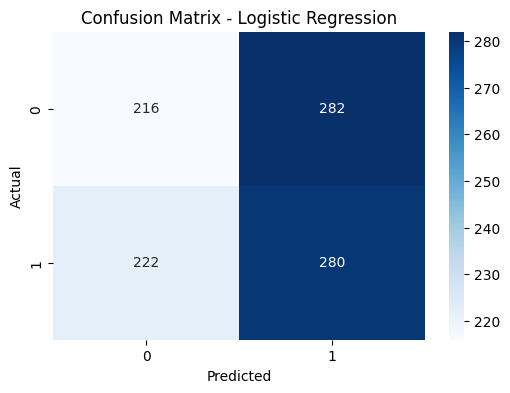

In [17]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
#Plot Feature Importance
if best_model_name == "Random Forest":
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title("Top 15 Feature Importances - Random Forest")
    plt.show()

In [20]:
#Save Best Model Pipeline
with open("../models/best_model_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [21]:
#Save Feature Columns
with open("../models/feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [22]:
#Save Model-Ready Dataset
df.to_csv("../data/final/model_ready_data.csv", index=False)

In [23]:
#Success Message
print("Best model pipeline and feature columns saved successfully!")

Best model pipeline and feature columns saved successfully!
